In [1]:
# --- core ---
import os, math, json, pathlib
# from dataclasses import dataclass
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

# --- your project modules (unchanged) ---
import scripts.preprocessing as PP          # NetworkConfig, Config, data utils  :contentReference[oaicite:0]{index=0}
import scripts.features as FE               # exogenous builders, utils          :contentReference[oaicite:1]{index=1}
import scripts.models as MD                 # EdgeSTGNN (do not modify)          :contentReference[oaicite:2]{index=2}
import scripts.training as TR               # train/eval utilities               :contentReference[oaicite:3]{index=3}
import scripts.visualisation as VIZ         # draw_network_flows                 :contentReference[oaicite:4]{index=4}
from scripts.preprocessing import Config, NetworkConfig

# plotting (only used in viz cells at the end)
import matplotlib.pyplot as plt


e:\Python\Bicycle_Traffic_Flow_GNN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
'''
todo's:
- add comments
- refactor code for clarity
- improve variable naming
- modularize code into functions
- remove hardcoded paths
- ensure consistent formatting
- add error handling
- optimize performance

mine:
- one day and one week lagged features
- more data months
- grid search for hyperparameters
- additional feature engineering
- cross-validation?
- showing non sensor locations on map
- feature grid search, show table of no features, features average on the gnn validation and only the one feature on the gnn validation


'''

"\ntodo's:\n- add comments\n- refactor code for clarity\n- improve variable naming\n- modularize code into functions\n- remove hardcoded paths\n- ensure consistent formatting\n- add error handling\n- optimize performance\n\nmine:\n- one day and one week lagged features\n- more data months\n- grid search for hyperparameters\n- additional feature engineering\n- cross-validation?\n- showing non sensor locations on map\n- feature grid search, show table of no features, features average on the gnn validation and only the one feature on the gnn validation\n\n\n"

In [3]:
# Keep randomness stable across runs (wraps your utility)  :contentReference[oaicite:5]{index=5}
def set_all_seeds(seed: int = 42):
    FE.set_seed(seed)

def make_splits(times: pd.DatetimeIndex, train=0.70, val=0.15):
    T = len(times)
    i_train = int(T * train)
    i_val   = i_train + int(T * val)
    return {
        "train": slice(0, i_train),
        "val":   slice(i_train, i_val),
        "test":  slice(i_val, T),
    }

# Build DataLoaders once from arrays + exog (shape-checked)  :contentReference[oaicite:6]{index=6}
def make_loaders(X, M, exog, cfg: PP.Config, splits):
    loaders = {}
    for split, sl in splits.items():
        ds = PP.WindowedEdgeDataset(X[sl], M[sl], (exog[sl] if exog is not None else None),
                                    cfg.H_in, cfg.H_out)     # __getitem__ signature unchanged  :contentReference[oaicite:7]{index=7}
        loaders[split] = DataLoader(ds, batch_size=cfg.batch_size,
                                    shuffle=(split=='train'), drop_last=True,
                                    pin_memory=str(cfg.device).startswith('cuda'))
    return loaders


def make_loaders_from_indices(X, M, exog, cfg, idx_train, idx_val, idx_test):
    def mk(idx):
        Xp = X[idx]; Mp = M[idx]; Ex = (exog[idx] if (exog is not None) else None)
        return PP.WindowedEdgeDataset(Xp, Mp, Ex, cfg.H_in, cfg.H_out)
    ds_tr, ds_va, ds_te = mk(idx_train), mk(idx_val), mk(idx_test)
    return {
        "train": torch.utils.data.DataLoader(ds_tr, batch_size=cfg.batch_size, shuffle=True,  drop_last=True),
        "val":   torch.utils.data.DataLoader(ds_va, batch_size=cfg.batch_size, shuffle=False, drop_last=False),
        "test":  torch.utils.data.DataLoader(ds_te, batch_size=cfg.batch_size, shuffle=False, drop_last=False),
    }


# Historical-mean baseline (per edge, per (dow, time-of-day) bin)
def fit_baseline_hmean(times: pd.DatetimeIndex, X: np.ndarray, M: np.ndarray):
    # key = (dow, minute-of-day)
    dow = times.dayofweek.to_numpy()
    mod = times.hour*60 + times.minute
    E = X.shape[1]
    # compute means causally over observed bins
    means = {}
    for e in range(E):
        df = pd.DataFrame({"dow": dow, "mod": mod, "x": X[:,e], "m": M[:,e] > 0.5})
        grp = df[df["m"]].groupby(["dow","mod"])["x"].mean()
        means[e] = grp.to_dict()
    def predict(idx: pd.DatetimeIndex) -> np.ndarray:
        d = idx.dayofweek.to_numpy()
        m = idx.hour*60 + idx.minute
        T = len(idx)
        out = np.zeros((T, E), dtype=np.float32)
        for e in range(E):
            md = means[e]
            for t in range(T):
                out[t,e] = md.get((int(d[t]), int(m[t])), 0.0)
        return out
    return predict

def hist_avg_time_of_day(X: np.ndarray,
                         M: np.ndarray,
                         times: pd.DatetimeIndex,
                         fit_slice: slice | None = None,
                         tz: str | None = None) -> np.ndarray:
    """
    Return Xhat_baseline[T,E]: for each time step, the mean count per edge
    over *all days* at the same time-of-day. Mask M is respected.

    Args
    ----
    X, M : [T,E] arrays (float32/float64). M=1 for observed, 0 otherwise.
    times: DatetimeIndex of length T.
    fit_slice: if given, compute the averages using times[fit_slice] only
               (e.g., splits['train']); otherwise use the full timeline.
    tz    : if set (e.g. 'Europe/Amsterdam'), convert times to that tz for the
            time-of-day grouping. If None, use times as-is.

    Returns
    -------
    Xhat : [T,E] baseline predictions.
    """
    # ensure tz if requested
    t = pd.DatetimeIndex(times)
    if tz is not None:
        t = (t.tz_localize('UTC').tz_convert(tz) if t.tz is None else t.tz_convert(tz))

    T, E = X.shape
    Xhat = np.zeros((T, E), dtype=np.float32)

    # time-of-day code in seconds from midnight (robust to any granularity)
    tod = (t.hour * 3600 + t.minute * 60 + t.second).astype(np.int32)

    # choose rows to compute the averages (fit set)
    fit_mask_rows = np.zeros(T, dtype=bool)
    if fit_slice is None:
        fit_mask_rows[:] = True
    else:
        fit_mask_rows[fit_slice] = True

    # precompute unique bins
    bins = np.unique(tod[fit_mask_rows])

    # compute per-edge mean for each time-of-day bin, then write back to all rows of that bin
    for b in bins:
        idx_all = (tod == b)               # all rows at this TOD (full T)
        idx_fit = idx_all & fit_mask_rows  # only rows used to compute the mean
        if not idx_fit.any():
            continue
        W = M[idx_fit, :]                        # [n,E]
        num = (X[idx_fit, :] * W).sum(axis=0)    # [E]
        den = W.sum(axis=0).clip(min=1.0)        # [E]
        mu  = (num / den).astype(np.float32)     # [E]
        Xhat[idx_all, :] = mu                    # broadcast same TOD-mean to all rows at that TOD

    return Xhat

# Simple per-edge linear regression on exogenous features (unchanged *inputs* idea)
# Uses numpy lstsq so we don't introduce new package deps.
def fit_linear_regression(X: np.ndarray, M: np.ndarray, exog: np.ndarray, train_slice: slice):
    # Train per edge to mirror original “edge-wise regression” intent
    Xtr = X[train_slice]      # [T,E]
    Mtr = M[train_slice]      # [T,E]
    Ftr = exog[train_slice]   # [T,E,F]
    T,E = X.shape
    F = Ftr.shape[2]
    W = np.zeros((E, F), dtype=np.float32)
    b = np.zeros((E,), dtype=np.float32)
    for e in range(E):
        mask = Mtr[:,e] > 0.5
        Xe = Ftr[:,e,:][mask]            # [N,F]
        ye = Xtr[:,e][mask][:,None]      # [N,1]
        if Xe.shape[0] >= F:
            # add bias column
            A = np.concatenate([Xe, np.ones((Xe.shape[0],1), np.float32)], axis=1)  # [N,F+1]
            sol, *_ = np.linalg.lstsq(A, ye, rcond=None)
            W[e,:] = sol[:-1,0]
            b[e]   = sol[-1,0]
        else:
            W[e,:] = 0.0; b[e] = 0.0
    def predict(exog_idx: np.ndarray) -> np.ndarray:
        Tn = exog_idx.shape[0]
        out = np.zeros((Tn, E), dtype=np.float32)
        for e in range(E):
            out[:,e] = exog_idx[:,e,:] @ W[e,:] + b[e]
        out[out < 0] = 0.0
        return out
    return predict


# Train ST-GNN exactly via your training loop (no functional changes)  :contentReference[oaicite:8]{index=8}
def train_stgnn(model, loaders, cfg: PP.Config, *, A_bin=None, epoch_hook=None):
    return TR.train_model(model, loaders, cfg, epoch_hook=epoch_hook, A_bin=A_bin)  # early-stop etc. unchanged  :contentReference[oaicite:9]{index=9}

# Rollout helper (uses your internal function to keep behaviour identical)  :contentReference[oaicite:10]{index=10}
def rollout_over_timeline(model, X, M, exog, H_in, H_out, device):
    return TR._rollout_preds_over_timeline(model, X, M, exog, H_in, H_out, device)  # one-step horizon placement preserved  :contentReference[oaicite:11]{index=11}

# Evaluation helper (your evaluate)  :contentReference[oaicite:12]{index=12}
def evaluate_loader(model, loader, device):
    return TR.evaluate(model, loader, device)


In [4]:
import pandas as pd
import numpy as np
from zoneinfo import ZoneInfo

def _pick_var(ds, candidates):
    names = {n.lower(): n for n in ds.data_vars}
    for cand in candidates:
        for lname, real in names.items():
            if cand in lname:
                return real
    return None

def load_davis_weather_nc(nc_paths, tz='Europe/Amsterdam', out_freq='5min'):
    """
    Read one or more Davis NetCDF files *without* dask and return a tz-aware
    DataFrame indexed in Europe/Amsterdam with columns:
      ['temp','wind','gust','rain','rain_rate']  (float32)
    - temp, wind = mean per interval
    - gust        = max per interval
    - rain        = mm per interval (from cumulative if available, else from rate)
    - rain_rate   = mean rate over interval
    """
    import xarray as xr

    AMS = ZoneInfo(tz)
    dfs = []

    for p in nc_paths:
        ds = xr.open_dataset(p)  # no dask needed for single-file
        # Pick available variables in THIS file
        var_temp = _pick_var(ds, ['air_temp','airtemperature','temperature','temp_out','temp'])
        var_wind = _pick_var(ds, ['wind_speed','windavg','wind','windspeed'])
        var_gust = _pick_var(ds, ['wind_gust','windgust','gust'])
        var_rain_cum  = _pick_var(ds, ['rain_cum','rain_total','precip_accum','precipitation_accum'])
        var_rain_rate = _pick_var(ds, ['rain_rate','precip_rate','precipitation_rate'])

        keep = [v for v in [var_temp, var_wind, var_gust, var_rain_cum, var_rain_rate] if v]
        if not keep:
            continue  # nothing useful in this file

        df = ds[keep].to_dataframe().reset_index()

        # normalise the time column
        time_col = 'time' if 'time' in df.columns else next(
            (c for c in df.columns if c.lower() in ('datetime','date','timestamp')), None
        )
        if time_col is None:
            raise RuntimeError(f"No time coordinate found in {p}")
        df['time'] = pd.to_datetime(df[time_col])

        # Assume UTC if naive, then convert to AMS
        if df['time'].dt.tz is None:
            df['time'] = df['time'].dt.tz_localize('UTC').dt.tz_convert(AMS)
        else:
            df['time'] = df['time'].dt.tz_convert(AMS)

        df = df.set_index('time').sort_index()

        # Resample to your model frequency
        agg = {}
        if var_temp: agg[var_temp] = 'mean'
        if var_wind: agg[var_wind] = 'mean'
        if var_gust: agg[var_gust] = 'max'
        if var_rain_rate: agg[var_rain_rate] = 'mean'
        if var_rain_cum:  agg[var_rain_cum] = 'last'
        rs = df.resample(out_freq).agg(agg)

        # Map to canonical names available in this file
        out = pd.DataFrame(index=rs.index)
        if var_temp:      out['temp']      = rs[var_temp]
        if var_wind:      out['wind']      = rs[var_wind]
        if var_gust:      out['gust']      = rs[var_gust]
        if var_rain_rate: out['rain_rate'] = rs[var_rain_rate]
        if var_rain_cum:  out['rain_cum']  = rs[var_rain_cum]  # temporary for diff

        dfs.append(out)

    if not dfs:
        raise RuntimeError("No expected weather variables found in the provided NetCDF files.")

    # Concatenate months and sort
    df_all = pd.concat(dfs, axis=0).sort_index()

    # Derive rain per interval (prefer cumulative if present)
    if 'rain_cum' in df_all.columns:
        df_all['rain'] = df_all['rain_cum'].diff().clip(lower=0)
    elif 'rain_rate' in df_all.columns:
        minutes = pd.to_timedelta(out_freq).components.minutes or 1
        df_all['rain'] = df_all['rain_rate'] * (minutes / 60.0)
    else:
        df_all['rain'] = np.nan

    # Ensure all requested columns exist
    for col in ['temp','wind','gust','rain_rate']:
        if col not in df_all.columns:
            df_all[col] = np.nan

    # Final selection & dtype
    return df_all[['temp','wind','gust','rain','rain_rate']].astype('float32')


In [5]:
import numpy as np, pandas as pd
from zoneinfo import ZoneInfo

# def make_stratified_day_split(times_ams: pd.DatetimeIndex,
#                               context_df: pd.DataFrame,
#                               ratios=(0.70, 0.15, 0.15),
#                               seed=42):
#     assert abs(sum(ratios) - 1) < 1e-6
#     rng = np.random.default_rng(seed)

#     t = pd.DatetimeIndex(times_ams)
#     days = t.normalize()
#     udays = days.unique().sort_values()

#     def day_flag(col):
#         if col not in context_df.columns:
#             return pd.Series(0, index=udays, dtype=int)
#         return (context_df[col]
#                 .groupby(days).max()
#                 .reindex(udays).fillna(0).astype(int))

#     W = day_flag("is_weekend")
#     H = day_flag("is_holiday")
#     E = day_flag("is_exam")

#     labels = []
#     for d in udays:
#         parts = []
#         if W.loc[d]: parts.append("W")
#         if H.loc[d]: parts.append("H")
#         if E.loc[d]: parts.append("E")
#         labels.append("+".join(parts) if parts else "None")
#     label = pd.Series(labels, index=udays, name="label")

#     train_days, val_days, test_days = [], [], []
#     for L in label.unique():
#         # pool of days for this label
#         pool = udays[label == L].to_numpy()   # <-- fixed
#         if pool.size == 0:
#             continue
#         perm = rng.permutation(pool)
#         n = len(perm)
#         n_tr = int(np.floor(ratios[0]*n))
#         n_va = int(np.floor(ratios[1]*n))
#         n_te = n - n_tr - n_va
#         train_days.extend(perm[:n_tr])
#         val_days.extend(perm[n_tr:n_tr+n_va])
#         test_days.extend(perm[n_tr+n_va:])

#     train_days = set(pd.DatetimeIndex(train_days))
#     val_days   = set(pd.DatetimeIndex(val_days))
#     test_days  = set(pd.DatetimeIndex(test_days))

#     idx_train = days.isin(train_days)
#     idx_val   = days.isin(val_days)
#     idx_test  = days.isin(test_days)


#     # small report
#     def pct(x): return f"{100*x:.1f}%"
#     def cat_share(dayset, flag):
#         if not dayset: return 0.0
#         dflags = flag.groupby(days).max().reindex(sorted(dayset)).fillna(0).astype(int)
#         return float(dflags.mean())

#     print("Days total:", len(udays))
#     for name, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
#         dset = set(days[idx])
#         print(f"{name:5s} days={len(dset):3d} | weekend={pct(cat_share(dset, W))} "
#               f"holiday={pct(cat_share(dset, H))} exam={pct(cat_share(dset, E))}")

#     return idx_train, idx_val, idx_test

In [ ]:
def _contiguous_slices_from_mask(mask: np.ndarray):
    """Return [start:stop] slices for each contiguous True region in mask."""
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    cuts = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[0, cuts + 1]
    ends   = np.r_[cuts, idx.size - 1]
    return [slice(idx[s], idx[e] + 1) for s, e in zip(starts, ends)]

def make_segmented_loader(X, M, exog, cfg, mask, shuffle, name="split"):
    """
    Concatenate window datasets from each contiguous True segment in `mask`,
    so windows never span removed-day gaps.
    """
    segs = _contiguous_slices_from_mask(mask)
    datasets = []
    for s in segs:
        Xs = X[s]; Ms = M[s]; Ex = (exog[s] if exog is not None else None)
        ds = PP.WindowedEdgeDataset(Xs, Ms, Ex, cfg.H_in, cfg.H_out)
        if len(ds) > 0:
            datasets.append(ds)
    if not datasets:
        raise ValueError(f"No windows for {name}. Try relaxing the split or H_in/H_out.")
    ds_all = torch.utils.data.ConcatDataset(datasets)
    return torch.utils.data.DataLoader(
        ds_all,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        drop_last=(name == "train"),
        pin_memory=str(cfg.device).startswith("cuda")
    )

def make_stratified_day_split(times_ams: pd.DatetimeIndex,
                              context_df: pd.DataFrame,
                              ratios=(0.70, 0.15, 0.15),
                              seed=42):
    """
    Stratify days by combined labels (Weekend/Holiday/Exam) and assign ~70/15/15.
    Uses Hamilton rounding per label-bucket, then globally rebalances to exact totals.

    Returns
    -------
    idx_train, idx_val, idx_test : np.ndarray of bool, shape (T,)
        Boolean masks over the full timeline (same length as times_ams).
    """
    assert len(ratios) == 3 and abs(sum(ratios) - 1.0) < 1e-6
    rng = np.random.default_rng(seed)

    # --- timeline (T) and unique days (N) ---
    t = pd.DatetimeIndex(times_ams)
    days = t.normalize()                # length T (per timestamp)
    udays = days.unique().sort_values() # length N (per unique day)

    # --- per-day flags from context_df (index assumed = times_ams) ---
    def day_flag(col):
        if col not in context_df.columns:
            return pd.Series(0, index=udays, dtype=int)
        return (context_df[col]
                .groupby(days).max()
                .reindex(udays).fillna(0).astype(int))

    W = day_flag("is_weekend")
    H = day_flag("is_holiday")
    E = day_flag("is_exam")

    # --- label each day by combination (handles overlaps) ---
    labels = []
    for d in udays:
        parts = []
        if W.loc[d]: parts.append("W")
        if H.loc[d]: parts.append("H")
        if E.loc[d]: parts.append("E")
        labels.append("+".join(parts) if parts else "None")
    label = pd.Series(labels, index=udays, name="label")

    # --- per-bucket Hamilton rounding (sums to bucket size) ---
    def _quota_counts(n, ratios_):
        raw = np.array(ratios_, dtype=float) * n
        base = np.floor(raw).astype(int)
        need = int(n - base.sum())
        if need > 0:
            rem = raw - base
            for j in np.argsort(rem)[::-1][:need]:
                base[j] += 1
        return base  # [q_train, q_val, q_test], sum = n

    # --- sample within each label bucket using its quota ---
    train_days, val_days, test_days = [], [], []
    for L in label.unique():
        pool = udays[label == L].to_numpy()
        n = len(pool)
        if n == 0:
            continue
        q_tr, q_va, q_te = _quota_counts(n, ratios)
        perm = rng.permutation(pool)
        train_days.extend(perm[:q_tr])
        val_days.extend(perm[q_tr:q_tr+q_va])
        test_days.extend(perm[q_tr+q_va:q_tr+q_va+q_te])

    # --- convert to disjoint sets ---
    train_days = set(pd.DatetimeIndex(train_days))
    val_days   = set(pd.DatetimeIndex(val_days)) - train_days
    test_days  = set(pd.DatetimeIndex(test_days)) - train_days - val_days

    # --- global totals target via Hamilton rounding (exact N) ---
    N = len(udays)
    raw_t = np.array(ratios, float) * N
    tgt   = np.floor(raw_t).astype(int)
    need  = int(N - tgt.sum())
    if need > 0:
        rem = raw_t - tgt
        for j in np.argsort(rem)[::-1][:need]:
            tgt[j] += 1
    target = tgt  # [Train, Val, Test], sums to N

    sets = [train_days, val_days, test_days]

    # --- global rebalance to hit exact totals (keep sets disjoint) ---
    def _rebalance_sets(sets_, target_, rng_):
        def sizes(): return np.array([len(s) for s in sets_], dtype=int)
        cur = sizes()
        guard = 200000
        # pool of all days to ensure we don't lose any
        all_days = set().union(*sets_)
        while guard > 0 and not np.all(cur == target_):
            surplus = np.argmax(cur - target_)
            deficit = np.argmin(cur - target_)
            if cur[surplus] <= target_[surplus] or cur[deficit] >= target_[deficit]:
                break
            # move a random day from surplus to deficit
            cand = list(sets_[surplus])
            if not cand:
                break
            d = cand[int(rng_.integers(len(cand)))]
            sets_[surplus].remove(d)
            sets_[deficit].add(d)
            cur = sizes()
            guard -= 1
        # final sanity: disjoint and cover target sum
        assert len(set().union(*sets_)) <= len(all_days)
        return sets_

    sets = _rebalance_sets(sets, target, rng)
    train_days, val_days, test_days = sets

    # --- boolean masks over full timeline (length T) ---
    idx_train = days.isin(train_days)
    idx_val   = days.isin(val_days)
    idx_test  = days.isin(test_days)

    # --- clear summary (within-split shares) ---
    def pct(x): return f"{100*x:.1f}%"
    def cat_share(dayset, flag_per_day: pd.Series):
        if not dayset:
            return 0.0
        idx = pd.DatetimeIndex(sorted(dayset))
        sel = flag_per_day.reindex(idx).fillna(0).astype(int)
        return float(sel.mean())

    print(f"Days total: {N}")
    for name, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
        dset = set(days[idx])
        print(f"{name:5s} days={len(dset):3d} | "
              f"weekend={pct(cat_share(dset, W))} "
              f"holiday={pct(cat_share(dset, H))} "
              f"exam={pct(cat_share(dset, E))}")

    return idx_train, idx_val, idx_test

In [7]:
from zoneinfo import ZoneInfo
AMS = ZoneInfo("Europe/Amsterdam")

def _expand_dates_or_ranges(items):
    out = set()
    if not items: return out
    for it in items:
        if isinstance(it, (tuple, list)) and len(it) == 2:
            s = pd.Timestamp(it[0], tz=AMS).normalize()
            e = pd.Timestamp(it[1], tz=AMS).normalize()
            rng = pd.date_range(s, e, freq="D", inclusive="both", tz=AMS)
            out.update(d.date() for d in rng)
        else:
            out.add(pd.Timestamp(it, tz=AMS).normalize().date())
    return out

def make_calendar_features(times_ams: pd.DatetimeIndex,
                           exam_ranges=None,
                           holiday_dates=None) -> pd.DataFrame:
    idx = pd.DatetimeIndex(times_ams)
    idx_ams = idx if idx.tz is not None else idx.tz_localize("UTC")
    idx_ams = idx_ams.tz_convert(AMS)
    dates = idx_ams.normalize().date

    d = pd.DataFrame(index=idx_ams)
    d["is_weekend"] = (idx_ams.dayofweek >= 5).astype("float32")

    d["is_exam"] = 0.0
    if exam_ranges:
        for s,e in exam_ranges:
            s = pd.Timestamp(s, tz=AMS).date()
            e = pd.Timestamp(e, tz=AMS).date()
            d.loc[(dates >= s) & (dates <= e), "is_exam"] = 1.0
    d["is_exam"] = d["is_exam"].astype("float32")

    d["is_holiday"] = 0.0
    hol = _expand_dates_or_ranges(holiday_dates)
    if hol:
        d.loc[pd.Series(dates, index=d.index).isin(hol), "is_holiday"] = 1.0
    d["is_holiday"] = d["is_holiday"].astype("float32")
    return d



In [ ]:
# ----------------------------
# 1) Network definition
# ----------------------------

'''one (Full), MAE 0.616/0.618'''
# # Nodes
# NODES = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# # Example coordinates in (x, y). Replace with your true values (meters or canvas units).
# POS = {
#     'A': (0, 10), 'B': (5, 10),
#     'C': (0, 7),  'D': (5, 7),
#     'E': (0, 4), 'F': (5, 4), 'G': (9, 4),
#     'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
#     'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
#     'P': (5, -5)
# }

# # Physical undirected links
# PHYSICAL_EDGES = [
#     ('A','B'),        # no sensor
#     ('A','C'),
#     ('C','E'),
#     ('B','D'),
#     ('D','F'),        # no sensor
#     ('C','D'),        # no sensor
#     ('D','G'),        # no sensor
#     ('G','K'),
#     ('K','O'),
#     ('H','I'),
#     ('I','J'),
#     ('J','K'),
#     ('K','L'),
#     ('E','I'),
#     ('F','J'),
#     ('J','N'),        # no sensor
#     ('N','P'),
#     ('I','M'),
#     ('M','N'),        # no sensor
#     ('N','O')         # no sensor
# ]

# # Edges without sensors (undirected listing). Both directions will be masked.
# NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('D','F'), ('J','N'), ('C','D')}


# # Map each (sensor_id|element_name) to its BASE direction (u->v).
# # count_in goes to (u->v); count_out goes to (v->u).
# SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
#     "TUD_SBX01|Line 0": ("D", "B"),
#     "TUD_SPX18|Line 0": ("A", "C"),
#     "TUD_SBX22|Line 0": ("E", "C"),
#     "TUD_SBXN6A|Line 2": ("F", "J"),
#     "TUD_SBXN6A|Line 0": ("J", "K"),
#     "TUD_SPX23|Line 0": ("I", "E"),
#     "TUD_SBX25|Line 2": ("I", "H"),
#     "TUD_SBX26|Line 0": ("I", "M"),
#     "TUD_SPX24|Line 0": ("J", "I"),
#     "TUD_SBX07-MULTI|Line 1": ("G", "K"),
#     "TUD_SBX07-MULTI|Line 2": ("K", "L"),
#     "TUD_SBX07-MULTI|Line 3": ("O", "K"),
#     "TUD_SBXN13|Line 0": ("P", "N"),
# }

'''Two (no F), MAE 0.617'''
# Nodes
NODES = ['A','B','C','D','E','G','H','I','J','K','L','M','N','O','P']

# Example coordinates in (x, y). Replace with your true values (meters or canvas units).
POS = {
    'A': (0, 10), 'B': (5, 10),
    'C': (0, 7),  'D': (5, 7),
    'E': (0, 4), 'G': (9, 4),
    'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
    'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
    'P': (5, -5)
}

# Physical undirected links
PHYSICAL_EDGES = [
    ('A','B'),        # no sensor
    ('A','C'),
    ('C','E'),
    ('B','D'),
    ('D','J'),
    ('C','D'),        # no sensor
    ('D','G'),        # no sensor
    ('G','K'),
    ('K','O'),
    ('H','I'),
    ('I','J'),
    ('J','K'),
    ('K','L'),
    ('E','I'),
    ('J','N'),        # no sensor
    ('N','P'),
    ('I','M'),
    ('M','N'),        # no sensor
    ('N','O')         # no sensor
]

# Edges without sensors (undirected listing). Both directions will be masked.
NO_SENSOR_UNDIR = {('A','B'), ('M','N'), ('N','O'), ('D','G'), ('J','N'), ('C','D')}

# Map each (sensor_id|element_name) to its BASE direction (u->v).
# count_in goes to (u->v); count_out goes to (v->u).
SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
    "TUD_SBX01|Line 0": ("D", "B"),
    "TUD_SPX18|Line 0": ("A", "C"),
    "TUD_SBX22|Line 0": ("E", "C"),
    "TUD_SBXN6A|Line 2": ("D", "J"),
    "TUD_SBXN6A|Line 0": ("J", "K"),
    "TUD_SPX23|Line 0": ("I", "E"),
    "TUD_SBX25|Line 2": ("I", "H"),
    "TUD_SBX26|Line 0": ("I", "M"),
    "TUD_SPX24|Line 0": ("J", "I"),
    "TUD_SBX07-MULTI|Line 1": ("G", "K"),
    "TUD_SBX07-MULTI|Line 2": ("K", "L"),
    "TUD_SBX07-MULTI|Line 3": ("O", "K"),
    "TUD_SBXN13|Line 0": ("P", "N"),
}

'''Three (no F, no AB connection), MAE 0.625'''
# # Nodes
# NODES = ['A','B','C','D','E','G','H','I','J','K','L','M','N','O','P']

# # Example coordinates in (x, y). Replace with your true values (meters or canvas units).
# POS = {
#     'A': (0, 10), 'B': (5, 10),
#     'C': (0, 7),  'D': (5, 7),
#     'E': (0, 4), 'G': (9, 4),
#     'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
#     'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
#     'P': (5, -5)
# }

# # Physical undirected links
# PHYSICAL_EDGES = [
#     ('A','C'),
#     ('C','E'),
#     ('B','D'),
#     ('D','J'),
#     ('C','D'),        # no sensor
#     ('D','G'),        # no sensor
#     ('G','K'),
#     ('K','O'),
#     ('H','I'),
#     ('I','J'),
#     ('J','K'),
#     ('K','L'),
#     ('E','I'),
#     ('J','N'),        # no sensor
#     ('N','P'),
#     ('I','M'),
#     ('M','N'),        # no sensor
#     ('N','O')         # no sensor
# ]

# # Edges without sensors (undirected listing). Both directions will be masked.
# NO_SENSOR_UNDIR = {('M','N'), ('N','O'), ('D','G'), ('J','N'), ('C','D')}

# # Map each (sensor_id|element_name) to its BASE direction (u->v).
# # count_in goes to (u->v); count_out goes to (v->u).
# SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
#     "TUD_SBX01|Line 0": ("D", "B"),
#     "TUD_SPX18|Line 0": ("A", "C"),
#     "TUD_SBX22|Line 0": ("E", "C"),
#     "TUD_SBXN6A|Line 2": ("D", "J"),
#     "TUD_SBXN6A|Line 0": ("J", "K"),
#     "TUD_SPX23|Line 0": ("I", "E"),
#     "TUD_SBX25|Line 2": ("I", "H"),
#     "TUD_SBX26|Line 0": ("I", "M"),
#     "TUD_SPX24|Line 0": ("J", "I"),
#     "TUD_SBX07-MULTI|Line 1": ("G", "K"),
#     "TUD_SBX07-MULTI|Line 2": ("K", "L"),
#     "TUD_SBX07-MULTI|Line 3": ("O", "K"),
#     "TUD_SBXN13|Line 0": ("P", "N"),
# }

'''Four (no F, no AB connection, no NO connection), MAE 0.628'''
# # Nodes
# NODES = ['A','B','C','D','E','G','H','I','J','K','L','M','N','O','P']

# # Example coordinates in (x, y). Replace with your true values (meters or canvas units).
# POS = {
#     'A': (0, 10), 'B': (5, 10),
#     'C': (0, 7),  'D': (5, 7),
#     'E': (0, 4), 'G': (9, 4),
#     'H': (-3, 1), 'I': (0, 1), 'J': (5, 1), 'K': (9, 1), 'L': (12, 1),
#     'M': (0, -2), 'N': (5, -2), 'O': (9, -2),
#     'P': (5, -5)
# }

# # Physical undirected links
# PHYSICAL_EDGES = [
#     ('A','C'),
#     ('C','E'),
#     ('B','D'),
#     ('D','J'),
#     ('C','D'),        # no sensor
#     ('D','G'),        # no sensor
#     ('G','K'),
#     ('K','O'),
#     ('H','I'),
#     ('I','J'),
#     ('J','K'),
#     ('K','L'),
#     ('E','I'),
#     ('J','N'),        # no sensor
#     ('N','P'),
#     ('I','M'),
#     ('M','N')        # no sensor
# ]

# # Edges without sensors (undirected listing). Both directions will be masked.
# NO_SENSOR_UNDIR = {('M','N'), ('D','G'), ('J','N'), ('C','D')}

# # Map each (sensor_id|element_name) to its BASE direction (u->v).
# # count_in goes to (u->v); count_out goes to (v->u).
# SENSOR_TO_EDGE: Dict[str, Tuple[str,str]] = {
#     "TUD_SBX01|Line 0": ("D", "B"),
#     "TUD_SPX18|Line 0": ("A", "C"),
#     "TUD_SBX22|Line 0": ("E", "C"),
#     "TUD_SBXN6A|Line 2": ("D", "J"),
#     "TUD_SBXN6A|Line 0": ("J", "K"),
#     "TUD_SPX23|Line 0": ("I", "E"),
#     "TUD_SBX25|Line 2": ("I", "H"),
#     "TUD_SBX26|Line 0": ("I", "M"),
#     "TUD_SPX24|Line 0": ("J", "I"),
#     "TUD_SBX07-MULTI|Line 1": ("G", "K"),
#     "TUD_SBX07-MULTI|Line 2": ("K", "L"),
#     "TUD_SBX07-MULTI|Line 3": ("O", "K"),
#     "TUD_SBXN13|Line 0": ("P", "N"),
# }


DIRECTED_EDGES = PP.undir_to_dir(PHYSICAL_EDGES)

EDGE_INDEX = {e:i for i,e in enumerate(DIRECTED_EDGES)}
INDEX_EDGE = {i:e for e,i in EDGE_INDEX.items()}

A_bin = PP.build_line_graph_adjacency(DIRECTED_EDGES, allow_uturn=False)
A_hat = PP.normalize_adjacency(A_bin)


net_cfg = PP.NetworkConfig(
    nodes=NODES,
    pos=POS,
    physical_edges=PHYSICAL_EDGES,
    no_sensor_undir=NO_SENSOR_UNDIR,
    sensor_to_edge=SENSOR_TO_EDGE,
    directed_edges=DIRECTED_EDGES,
    edge_index=EDGE_INDEX,
    index_edge=INDEX_EDGE,
    a_line=A_bin,
    a_hat=A_hat
)

E = len(net_cfg.directed_edges)
E



34

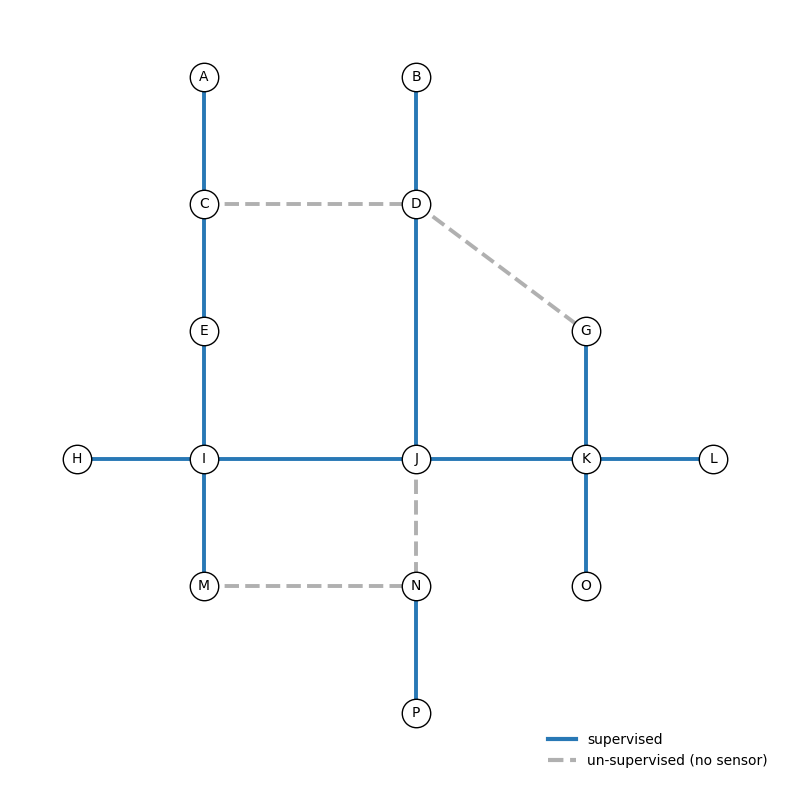

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- helpers ---
def undirected(edge):
    u, v = edge
    return tuple(sorted((u, v)))

# --- build undirected edge sets ---
phys_undir      = {undirected(e) for e in PHYSICAL_EDGES}
no_sensor_undir = {undirected(e) for e in NO_SENSOR_UNDIR}
supervised_undir = phys_undir - no_sensor_undir  # everything else has sensors

# --- graph ---
G = nx.Graph()
G.add_nodes_from(NODES)
G.add_edges_from(phys_undir)

# --- draw ---
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, POS, node_size=420, node_color="white",
                       edgecolors="black", linewidths=1.0)
# supervised edges: solid, stronger color
nx.draw_networkx_edges(G, POS, edgelist=list(supervised_undir),
                       width=2.8, edge_color="#2878b5")
# unsupervised edges: dashed, light gray
nx.draw_networkx_edges(G, POS, edgelist=list(no_sensor_undir),
                       width=2.8, style="--", edge_color="#b0b0b0")

nx.draw_networkx_labels(G, POS, font_size=10)
# plt.title("Network: sensor-supervised vs unsupervised (no sensor)")
plt.axis("off")

# legend
handles = [
    Line2D([0],[0], color="#2878b5", lw=3.0, label="supervised"),
    Line2D([0],[0], color="#b0b0b0", lw=3.0, ls="--", label="un-supervised (no sensor)"),
]
plt.legend(handles=handles, loc="lower right", frameon=False)
plt.tight_layout()
plt.show()


In [10]:
# cfg = PP.Config()                 # grit: H_in/H_out, batch, etc.  :contentReference[oaicite:17]{index=17}
time_granularity = "15min"
H_in = FE.steps_for_hours(time_granularity, 6)          # hours in the past
H_out = FE.steps_for_hours(time_granularity, 3)         # hours in the future

cfg = PP.Config(
    time_granularity = time_granularity,
    H_in = H_in,
    H_out = H_out,
    batch_size=64,
    lr=1e-4,
    max_epochs=20,
    patience=8,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    use_exog=True,
    gcn_type="cheb",     # or "gcn"
    cheb_K=3,            # 2–4 is typical
    nblocks=2,           # gives 1–2–4 dilations
    hidden=32,
    dropout=0.12,
    lambda_lap=1e-3 
)
set_all_seeds(cfg.seed)

# Load your raw CSVs exactly as before
csv_paths = [
    "data/smartcameras_line--2025-01-01T03-01-00--2025-02-01T03-01-00--tud_project--y16mv1.csv",
    "data/smartcameras_line--2025-02-01T03-01-00--2025-03-01T03-01-00--tud_project--bvtmix.csv",
    "data/smartcameras_line--2025-03-01T03-01-00--2025-04-01T03-01-00--tud_project--a93fyx.csv",
    "data/smartcameras_line--2025-04-01T03-01-00--2025-05-01T03-01-00--tud_project--henvbs.csv"
]
raw_df = PP.parse_smartcamera_csv(csv_paths)      # tidy: timestamp, sensor_key, count_in, count_out  :contentReference[oaicite:18]{index=18}

nc_paths = [
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202501.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202502.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202503.nc",
    "data/davis-TUD-EWI_Roof_Electrical_Engineering_202504.nc"
]
weather_raw = load_davis_weather_nc(nc_paths, tz='Europe/Amsterdam', out_freq=cfg.time_granularity)
weather_raw.head()

# Build edge-time matrices (targets + mask) from your mapping
times, X, M = PP.build_edge_time_matrix(raw_df, cfg, net_cfg)   # returns times[T], X[T,E], M[T,E]  :contentReference[oaicite:19]{index=19}
times[:3], X.shape, M.shape


(DatetimeIndex(['2025-01-01 03:00:00', '2025-01-01 03:15:00',
                '2025-01-01 03:30:00'],
               dtype='datetime64[ns]', name='timestamp', freq='15min'),
 (11521, 34),
 (11521, 34))

In [11]:
# from zoneinfo import ZoneInfo
# AMS = ZoneInfo('Europe/Amsterdam')

# # Make train/val/test splits (70/15/15)
# splits = make_splits(times, train=0.70, val=0.15)

# # 0) Make an Amsterdam-local timeline for feature building
# times_idx = pd.DatetimeIndex(times)
# times_ams = (times_idx.tz_localize('UTC').tz_convert(AMS)
#              if times_idx.tz is None else times_idx.tz_convert(AMS))

# # 1) Ensure weather is Amsterdam-local and at your model granularity
# w = weather_raw.copy()
# if w.index.tz is None:
#     w.index = w.index.tz_localize('UTC').tz_convert(AMS)
# else:
#     w.index = w.index.tz_convert(AMS)
# w = w.resample(cfg.time_granularity).mean()

# # 2) Align to the model timeline (causal fill; no symmetric interpolation)
# weather_df = w.reindex(times_ams).ffill()
# weather_df = weather_df.ffill().bfill()

# # 3) (Recommended) standardise per-channel using ONLY the train split
# mu  = weather_df.iloc[splits['train']].mean()
# std = weather_df.iloc[splits['train']].std().replace(0, 1.0)
# weather_df = ((weather_df - mu) / std).astype('float32')

# # 4) Build exogenous features (time-of-day/dow + weather + lags), broadcasted to all edges
# # Exogenous features builder: time-of-day/day-of-week (+ optional weather),
# # plus causal self & neighbour lags (uses your exact implementation).  :contentReference[oaicite:20]{index=20}
# exog = FE.add_exogenous(
#     times=times_ams, E=E, config=cfg, weather_df=weather_df,
#     X=X, M=M, A_bin=A_bin,
#     use_graph_fill=True,
#     lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
#     ema_alpha=0.7, fill_weights=(0.7, 0.3, 0.0),  # no preds mixed in for initial exog
#     Xhat_prev=None
# )
# exog = np.asarray(exog, dtype=np.float32)
# exog = np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

# exog.shape


In [12]:
# import numpy as np
# import pandas as pd
# from zoneinfo import ZoneInfo

# AMS = ZoneInfo('Europe/Amsterdam')

# # Make train/val/test splits (70/15/15)
# splits = make_splits(times, train=0.70, val=0.15)

# # --- 0) Single source of truth for the feature timeline ---
# times_idx = pd.DatetimeIndex(times)
# times_ams = (times_idx.tz_localize('UTC').tz_convert(AMS)
#              if times_idx.tz is None else times_idx.tz_convert(AMS))

# # --- 1) Weather -> align to times_ams, causal fill, train-only scaling ---
# w = weather_raw.copy()
# if w.index.tz is None:  # assume raw is UTC if naive
#     w.index = w.index.tz_localize('UTC').tz_convert(AMS)
# else:
#     w.index = w.index.tz_convert(AMS)

# w = w.resample(cfg.time_granularity).mean()
# weather_df = w.reindex(times_ams).ffill().bfill()               # bfill only to remove initial NaNs

# mu  = weather_df.iloc[splits['train']].mean()
# std = weather_df.iloc[splits['train']].std().replace(0, 1.0)
# weather_df = ((weather_df - mu) / std).astype('float32')

# # eliminate any stragglers
# weather_df = weather_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)


# exam_ranges = [
#     ("2025-01-20","2025-01-31"),
# ]
# holiday_dates = [
#     ("2025-01-01","2025-01-05"),
#     ("2025-02-01","2025-02-09"),
#     ("2025-04-18","2025-04-21"),
#     # add more dates or ranges as needed
# ]

# cal_df = make_calendar_features(times_ams, exam_ranges=exam_ranges, holiday_dates=holiday_dates)
# context_df = pd.concat([weather_df, cal_df], axis=1).astype("float32")


# # --- 2) Build exogenous on the SAME timeline; then harden to finite ---
# exog = FE.add_exogenous(
#     times=times_ams, E=E, config=cfg, weather_df=context_df,
#     X=X, M=M, A_bin=A_bin,
#     use_graph_fill=True,
#     lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
#     ema_alpha=0.7, fill_weights=(0.7, 0.3, 0.0),
#     Xhat_prev=None
# ).astype('float32')

# # force-finite (protects against any NaN from early lags/edge cases)
# exog = np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

# # quick diagnostics
# if not np.isfinite(exog).all():
#     bad_t = np.unique(np.where(~np.isfinite(exog))[0])[:10]
#     print("First bad timestamps:", times_ams[bad_t])

In [13]:
import numpy as np
import pandas as pd
from zoneinfo import ZoneInfo

AMS = ZoneInfo('Europe/Amsterdam')

# --- 0) Single source of truth for the feature timeline ---
times_idx = pd.DatetimeIndex(times)
times_ams = (times_idx.tz_localize('UTC').tz_convert(AMS)
             if times_idx.tz is None else times_idx.tz_convert(AMS))

# --- 1) Calendar flags (needed for stratified split) ---
exam_ranges = [
    ("2025-01-20","2025-01-31"),
    ("2025-04-07","2025-04-17"),
]
holiday_dates = [
    ("2025-01-01","2025-01-05"),
    ("2025-02-01","2025-02-09"),
    ("2025-04-18","2025-04-21"),
]
cal_df = make_calendar_features(times_ams, exam_ranges=exam_ranges, holiday_dates=holiday_dates)

# --- 2) Stratified 70/15/15 split over day categories (weekend/holiday/exam) ---
# Assumes make_stratified_day_split(...) is defined (from earlier cell)
idx_train, idx_val, idx_test = make_stratified_day_split(
    times_ams, cal_df, ratios=(0.70, 0.15, 0.15), seed=42
)

# (Optional) keep a dict if other code expects split masks
splits_idx = {"train": idx_train, "val": idx_val, "test": idx_test}

# --- 3) Weather -> align to times_ams, causal fill, TRAIN-only scaling ---
w = weather_raw.copy()
if w.index.tz is None:  # assume raw is UTC if naive
    w.index = w.index.tz_localize('UTC').tz_convert(AMS)
else:
    w.index = w.index.tz_convert(AMS)
w = w.resample(cfg.time_granularity).mean()

weather_df = w.reindex(times_ams).ffill().bfill()  # bfill only to remove initial NaNs

# scale using TRAIN mask (boolean index)
mu  = weather_df.iloc[idx_train].mean()
std = weather_df.iloc[idx_train].std().replace(0, 1.0)
weather_df = ((weather_df - mu) / std).astype('float32')

# eliminate any stragglers
weather_df = weather_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# --- 4) Context = weather + calendar flags ---
context_df = pd.concat([weather_df, cal_df], axis=1).astype("float32")

# --- 5) Exogenous features with lags: 1,2,3, 24h, 1 week ---
L24 = FE.steps_for_hours(cfg.time_granularity, 24)       # e.g., 96 for 15-min bins
L7d = FE.steps_for_hours(cfg.time_granularity, 24*7)     # e.g., 672 for 15-min bins
lags_self  = tuple(sorted(set([1, 2, 3, int(L24), int(L7d)])))
lags_neigh = (1, 2, 3)

exog = FE.add_exogenous(
    times=times_ams, E=E, config=cfg, weather_df=context_df,
    X=X, M=M, A_bin=A_bin,
    use_graph_fill=True,
    lags_self=lags_self, lags_neigh=lags_neigh,
    ema_alpha=0.7, fill_weights=(0.7, 0.3, 0.0),
    Xhat_prev=None
).astype('float32')

# force-finite (protects against any NaN from early lags/edge cases)
exog = np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

# quick diagnostics
if not np.isfinite(exog).all():
    bad_t = np.unique(np.where(~np.isfinite(exog))[0])[:10]
    print("First bad timestamps:", times_ams[bad_t])


Days total: 121
train days= 85 | weekend=29.4% holiday=15.3% exam=18.8%
val   days= 18 | weekend=22.2% holiday=11.1% exam=22.2%
test  days= 18 | weekend=27.8% holiday=16.7% exam=16.7%


In [15]:
loaders = {
    "train": make_segmented_loader(X, M, (exog if cfg.use_exog else None), cfg, idx_train, True,  "train"),
    "val":   make_segmented_loader(X, M, (exog if cfg.use_exog else None), cfg, idx_val,   False, "val"),
    "test":  make_segmented_loader(X, M, (exog if cfg.use_exog else None), cfg, idx_test,  False, "test"),
}

NameError: name 'make_segmented_loader' is not defined

In [14]:
# # pred_hmean = fit_baseline_hmean(times, X, M)    # per-edge, per (DoW, minute-of-day)
# Xhat_baseline = pred_hmean(times)               # [T,E]

Xhat_baseline = hist_avg_time_of_day(X, M, times, fit_slice=splits["train"], tz=AMS)


NameError: name 'splits' is not defined

In [ ]:
# Train per-edge linear regression on exogenous features
reg_predict = fit_linear_regression(X, M, exog, train_slice=splits["train"])
Xhat_reg = reg_predict(exog)   # [T,E]


In [ ]:
# === Full powerset grid (including the empty set) + per-feature averages + top-5 combos ===
import itertools, time, numpy as np, pandas as pd, torch

# Assumptions:
# - times_ams, context_df (weather + calendar flags), X, M, E, A_bin, A_hat, splits, cfg, FE, PP, TR, MD
# - helpers: make_loaders, fit_linear_regression, train_stgnn, evaluate_loader

candidate_cols = [c for c in [
    "temp", "wind","gust","rain","rain_rate",      # weather
    "is_weekend","is_exam","is_holiday",          # calendar
    # add more names if you actually have 9 total
] if c in context_df.columns]
print(f"Candidate features (N={len(candidate_cols)}): {candidate_cols}")

use_prediction_hook = False   # set True if you usually train with the hook
max_combos = None             # cap if needed; None = all (2^N)

def masked_mae_np(yhat, y, m):
    num = np.abs(yhat - y) * m
    den = np.clip(m.sum(), 1.0, None)
    return float(num.sum() / den)

def feature_combos_all_including_empty(cols):
    for r in range(0, len(cols) + 1):            # <-- includes r=0 (empty set)
        for comb in itertools.combinations(cols, r):
            yield comb

def build_exog_from_subset(selected_cols):
    ctx = context_df[selected_cols] if selected_cols else pd.DataFrame(index=context_df.index)
    exog = FE.add_exogenous(
        times=times_ams, E=E, config=cfg, weather_df=ctx,
        X=X, M=M, A_bin=A_bin,
        use_graph_fill=True,
        lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
        ema_alpha=0.7, fill_weights=(0.7,0.3,0.0),
        Xhat_prev=None
    ).astype("float32")
    return np.nan_to_num(exog, nan=0.0, posinf=0.0, neginf=0.0)

def make_finite_epoch_hook(X, M, times, E, cfg, context_df_subset, A_bin, splits,
                           lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
                           ema_alpha=0.7, fill_weights=(0.5,0.3,0.2), exog_init=None):
    holder = {"arr": (exog_init if exog_init is not None else
                      FE.add_exogenous(times, E, cfg, context_df_subset,
                                       X=X, M=M, A_bin=A_bin, use_graph_fill=True,
                                       lags_self=lags_self, lags_neigh=lags_neigh,
                                       ema_alpha=ema_alpha, fill_weights=(0.7,0.3,0.0),
                                       Xhat_prev=None).astype('float32'))}
    holder["arr"] = np.nan_to_num(holder["arr"], nan=0.0, posinf=0.0, neginf=0.0)
    def epoch_hook(epoch, model, loaders_dict):
        Xhat = TR._rollout_preds_over_timeline(model, X, M, holder["arr"], cfg.H_in, cfg.H_out, cfg.device)
        ex_new = FE.add_exogenous(times, E, cfg, context_df_subset,
                                  X=X, M=M, A_bin=A_bin, use_graph_fill=True,
                                  lags_self=lags_self, lags_neigh=lags_neigh,
                                  ema_alpha=ema_alpha, fill_weights=fill_weights,
                                  Xhat_prev=Xhat).astype('float32')
        ex_new = np.nan_to_num(ex_new, nan=0.0, posinf=0.0, neginf=0.0)
        holder["arr"] = ex_new
        for split in ("train", "val"):
            s = splits[split]
            ds = PP.WindowedEdgeDataset(X[s], M[s], ex_new[s], cfg.H_in, cfg.H_out)
            loaders_dict[split] = torch.utils.data.DataLoader(
                ds, batch_size=cfg.batch_size, shuffle=(split=="train"), drop_last=True,
                pin_memory=str(cfg.device).startswith("cuda")
            )
    return epoch_hook

all_combs = list(feature_combos_all_including_empty(candidate_cols))
if max_combos is not None:
    all_combs = all_combs[:max_combos]
print(f"Total settings to evaluate: {len(all_combs)}")  # = 2^N

results = []
start_all = time.time()

for i, comb in enumerate(all_combs, 1):
    label = "(none)" if len(comb)==0 else "+".join(comb)
    print(f"[{i}/{len(all_combs)}] {label}")

    # 1) exogenous for this subset
    exog = build_exog_from_subset(list(comb))

    # 2) Regression baseline
    reg_predict = fit_linear_regression(X, M, exog, train_slice=splits["train"])
    Xhat_reg = reg_predict(exog)
    mae_reg_val  = masked_mae_np(Xhat_reg[splits["val"]],  X[splits["val"]],  M[splits["val"]])
    mae_reg_test = masked_mae_np(Xhat_reg[splits["test"]], X[splits["test"]], M[splits["test"]])

    # 3) GNN
    loaders = make_loaders(X, M, (exog if cfg.use_exog else None), cfg, splits)
    F_in = 1 + (exog.shape[2] if cfg.use_exog else 0)
    gnn = MD.EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat,
                       nblocks=cfg.nblocks, hidden=cfg.hidden, dropout=cfg.dropout,
                       gcn_type=cfg.gcn_type, cheb_K=getattr(cfg, "cheb_K", 3)).to(cfg.device)

    if use_prediction_hook:
        ctx_subset = context_df[list(comb)] if comb else pd.DataFrame(index=context_df.index)
        epoch_hook = make_finite_epoch_hook(X, M, times_ams, E, cfg, ctx_subset, A_bin, splits, exog_init=exog)
    else:
        epoch_hook = None

    t0 = time.time()
    gnn = train_stgnn(gnn, loaders, cfg, A_bin=A_bin, epoch_hook=epoch_hook)
    dur = time.time() - t0

    val_metrics  = evaluate_loader(gnn, loaders["val"],  cfg.device)
    test_metrics = evaluate_loader(gnn, loaders["test"], cfg.device)

    results.append({
        "features_on": label,
        "combo": tuple(comb),  # <-- save the actual tuple for later analysis
        "k_on": len(comb),
        "reg_val_MAE":  float(mae_reg_val),
        "reg_test_MAE": float(mae_reg_test),
        "gnn_val_MAE":  float(val_metrics.get("MAE", np.nan)),
        "gnn_test_MAE": float(test_metrics.get("MAE", np.nan)),
        "train_seconds": round(dur, 2),
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

res_df = pd.DataFrame(results).sort_values(["gnn_val_MAE","reg_val_MAE","k_on"]).reset_index(drop=True)
print(f"Grid done over {len(res_df)} settings in {time.time()-start_all:.1f}s")

# ---- Per-feature average MAE (across every combination that includes the feature) ----
rows = []
for f in candidate_cols:
    sel = res_df[res_df["combo"].apply(lambda c: f in c)]
    rows.append({
        "feature": f,
        "combos_count": int(sel.shape[0]),
        "gnn_val_MAE_mean":  float(sel["gnn_val_MAE"].mean()),
        "gnn_test_MAE_mean": float(sel["gnn_test_MAE"].mean()),
        "reg_val_MAE_mean":  float(sel["reg_val_MAE"].mean()),
        "reg_test_MAE_mean": float(sel["reg_test_MAE"].mean()),
    })
feature_avg = pd.DataFrame(rows).sort_values("gnn_val_MAE_mean", ascending=True).reset_index(drop=True)

# ---- Top-5 combinations by GNN val MAE (ties broken by reg val MAE, then smaller k) ----
top5 = res_df.sort_values(["gnn_val_MAE","reg_val_MAE","k_on"]).head(5)

display(feature_avg)
display(top5[["features_on","k_on","gnn_val_MAE","reg_val_MAE","gnn_test_MAE","reg_test_MAE","train_seconds"]])


Candidate features (N=1): ['temp']
Total settings to evaluate: 2
[1/2] (none)


Epochs:   5%|▌         | 1/20 [00:03<01:13,  3.85s/it]

epoch 001  train_mae=1.7990  val_mae=1.2365


Epochs:  10%|█         | 2/20 [00:06<00:57,  3.22s/it]

epoch 002  train_mae=1.6029  val_mae=1.1223


...

Epochs: 100%|██████████| 20/20 [00:58<00:00,  2.92s/it]

epoch 020  train_mae=1.2952  val_mae=0.8055


Grid done over 2 settings in 118.6s


,feature,combos_count,gnn_val_MAE_mean,gnn_test_MAE_mean,reg_val_MAE_mean,reg_test_MAE_mean
0,temp,1,0.805511,0.791499,0.71972,0.699884


,features_on,k_on,gnn_val_MAE,reg_val_MAE,gnn_test_MAE,reg_test_MAE,train_seconds
0,temp,1,0.805511,0.71972,0.791499,0.699884,58.34
1,(none),0,0.807154,0.71972,0.791545,0.699884,58.78


In [ ]:
display(feature_avg)
display(top5[["features_on","k_on","gnn_val_MAE","reg_val_MAE","gnn_test_MAE","reg_test_MAE","train_seconds"]])

,feature,combos_count,gnn_val_MAE_mean,gnn_test_MAE_mean,reg_val_MAE_mean,reg_test_MAE_mean
0,temp,1,0.805511,0.791499,0.71972,0.699884


,features_on,k_on,gnn_val_MAE,reg_val_MAE,gnn_test_MAE,reg_test_MAE,train_seconds
0,temp,1,0.805511,0.71972,0.791499,0.699884,58.34
1,(none),0,0.807154,0.71972,0.791545,0.699884,58.78


In [ ]:
# --- Show MAE for the empty set (no extra features) ---
none_row = res_df.loc[res_df["features_on"] == "(none)"]
if none_row.empty:
    print("Empty-set result not found (did the loop include r=0?).")
else:
    r = none_row.iloc[0]
    print(
        "Empty-set (no extra context) — "
        f"GNN val MAE: {r['gnn_val_MAE']:.4f}, test MAE: {r['gnn_test_MAE']:.4f}; "
        f"REG val MAE: {r['reg_val_MAE']:.4f}, test MAE: {r['reg_test_MAE']:.4f}"
    )
    display(none_row[["features_on","k_on","gnn_val_MAE","reg_val_MAE","gnn_test_MAE","reg_test_MAE","train_seconds"]])


Empty-set (no extra context) — GNN val MAE: 0.8072, test MAE: 0.7915; REG val MAE: 0.7197, test MAE: 0.6999


,features_on,k_on,gnn_val_MAE,reg_val_MAE,gnn_test_MAE,reg_test_MAE,train_seconds
1,(none),0,0.807154,0.71972,0.791545,0.699884,58.78


In [ ]:
# import dataclasses, itertools, pandas as pd, numpy as np, time

# grid = {
#     "lr":       [1e-4, 3e-4],
#     "hidden":   [32, 64],
#     "nblocks":  [2, 3],
#     "dropout":  [0.1, 0.2],
#     "gcn_type": ["cheb"],   # or ["gcn","cheb"]
#     "cheb_K":   [2, 3],
# }

# def run_one(cfg0, params):
#     cfg = dataclasses.replace(cfg0, **params,
#                               max_epochs=min(cfg0.max_epochs, 15),
#                               patience=min(cfg0.patience, 5))
#     F_in = 1 + (exog.shape[2] if cfg.use_exog else 0)
#     model = MD.EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat,
#                          nblocks=cfg.nblocks, hidden=cfg.hidden, dropout=cfg.dropout,
#                          gcn_type=cfg.gcn_type, cheb_K=getattr(cfg, "cheb_K", 3)).to(cfg.device)  # :contentReference[oaicite:5]{index=5}
#     loaders_gs = make_loaders_norm(X, M, (exog if cfg.use_exog else None), cfg, splits)
#     t0 = time.time()
#     model = TR.train_model(model, loaders_gs, cfg, A_bin=A_bin)       # :contentReference[oaicite:6]{index=6}
#     dur = time.time() - t0
#     val = TR.evaluate(model, loaders_gs["val"], cfg.device)["MAE"]    # :contentReference[oaicite:7]{index=7}
#     tst = TR.evaluate(model, loaders_gs["test"], cfg.device)["MAE"]
#     return {"val": float(val), "test": float(tst), "sec": round(dur,2), **params}

# keys, values = zip(*grid.items())
# rows = []
# for comb in itertools.product(*values):
#     params = dict(zip(keys, comb))
#     rows.append(run_one(cfg, params))
# gs_df = pd.DataFrame(rows).sort_values("val").reset_index(drop=True)
# display(gs_df.head(10))
# best = gs_df.iloc[0].to_dict()
# print("Best (by val MAE):", best)


NameError: name 'make_loaders_norm' is not defined

In [ ]:
# Determine input feature dimension seen by the model:
# WindowedEdgeDataset concatenates the raw count channel with exog on the *history* side
# so per-timestep feature depth = 1 + F_exog (unchanged)  :contentReference[oaicite:21]{index=21}
F_in = 1 + (exog.shape[2] if cfg.use_exog and exog is not None else 0)

# DataLoaders for train/val/test
loaders = make_loaders(X, M, (exog if cfg.use_exog else None), cfg, splits)

# Instantiate your model exactly as before (same hyperparams / options)
gnn = MD.EdgeSTGNN(E=E, F_in=F_in, H_out=cfg.H_out, A_hat=A_hat,
                   nblocks=cfg.nblocks, hidden=cfg.hidden, dropout=cfg.dropout, gcn_type=cfg.gcn_type)   # unchanged internals  :contentReference[oaicite:22]{index=22}

# (Optional) prediction-driven epoch hook: keeps behaviour identical to your script  :contentReference[oaicite:23]{index=23}
# epoch_hook = None
# If you previously used the hook, uncomment:
epoch_hook = TR.make_prediction_driven_hook(
    X, M, times_ams, E, cfg, context_df, A_bin,
    slices=splits, loaders=loaders,
    lags_self=(1,2,3,6,12), lags_neigh=(1,2,3),
    ema_alpha=0.7, fill_weights=(0.5, 0.3, 0.2)  # includes predictions
)

# Train (identical loop with early-stop & optional Laplacian smoothing)  :contentReference[oaicite:24]{index=24}
gnn = train_stgnn(gnn, loaders, cfg, A_bin=A_bin, epoch_hook=None)


Epochs:   5%|▌         | 1/20 [00:01<00:26,  1.39s/it]

epoch 001  train_mae=1.5593  val_mae=1.2593


Epochs:  10%|█         | 2/20 [00:02<00:25,  1.43s/it]

epoch 002  train_mae=1.4983  val_mae=1.2849


Epochs:  15%|█▌        | 3/20 [00:04<00:24,  1.45s/it]

...

epoch 018  train_mae=1.0678  val_mae=0.7814


Epochs:  95%|█████████▌| 19/20 [00:26<00:01,  1.35s/it]

epoch 019  train_mae=1.0638  val_mae=0.7776


Epochs: 100%|██████████| 20/20 [00:27<00:00,  1.38s/it]

epoch 020  train_mae=1.0601  val_mae=0.7748


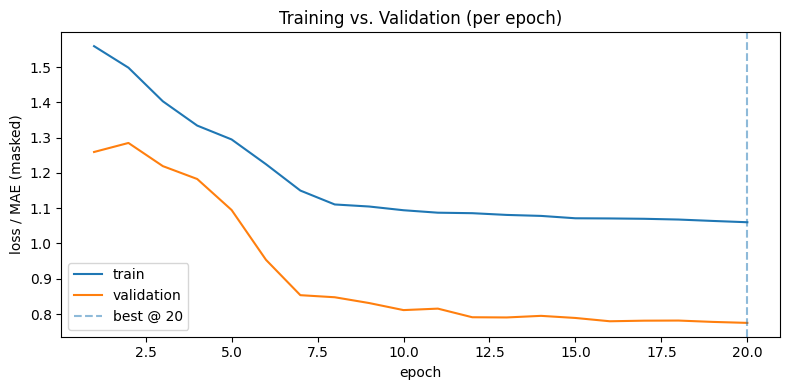

[1.5592624339901033, 1.4982576936971945, 1.4030208314051393, 1.3341383152320736, 1.2948484205808797, 1.224642402813083, 1.1499266829647001, 1.110527265267294, 1.104718246420876, 1.0941699909382179, 1.0871956885838119, 1.0857973890226396, 1.080889805418546, 1.07810442858055, 1.071374656724148, 1.0708850084758195, 1.069909685947856, 1.0677844686586349, 1.0638019364388263, 1.060115743855961]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

h = getattr(gnn, "history", None)
if not h:
    raise RuntimeError("No history found. Re-run training to populate model.history.")

epochs = np.array(h["epoch"])
train  = np.array(h["train"])
val    = np.array(h["val"])
best_ix = int(np.argmin(val))

plt.figure(figsize=(8,4))
plt.plot(epochs, train, label="train")
plt.plot(epochs, val,   label="validation")
plt.axvline(epochs[best_ix], linestyle="--", alpha=0.5, label=f"best @ {epochs[best_ix]}")
plt.title("Training vs. Validation (per epoch)")
plt.xlabel("epoch")
plt.ylabel("loss / MAE (masked)")
plt.legend()
plt.tight_layout()
plt.show()

print(h["train"])


In [ ]:
# Rebuild exog for the full timeline if needed (above already computed for full T)
Xhat_gnn = rollout_over_timeline(gnn, X, M, exog, cfg.H_in, cfg.H_out, cfg.device)  # [T,E]  :contentReference[oaicite:25]{index=25}


In [ ]:
import numpy as np
import pandas as pd

def make_df_pred(times, X, M, preds, net_cfg, model_name="gnn"):
    """
    times: DatetimeIndex of length T
    X:      [T,E] true counts
    M:      [T,E] mask (1 if observed)
    preds:  [T,E] predictions aligned to times (next-step rollout)
    net_cfg: holds directed_edges, edge_index, etc.
    """
    times = pd.DatetimeIndex(times)
    T, E = X.shape
    assert preds.shape == (T, E), f"preds shape {preds.shape} != {(T,E)}"

    edges = list(net_cfg.directed_edges)  # [(u,v), ...]
    u = np.array([e[0] for e in edges])
    v = np.array([e[1] for e in edges])

    # tile edge columns over time
    df = pd.DataFrame({
        "timestamp": np.repeat(times.values, E),
        "u": np.tile(u, T),
        "v": np.tile(v, T),
        "true": X.reshape(-1),
        "pred": preds.reshape(-1),
        "observed": (M.reshape(-1) > 0.5),
        "h": 0,                     # one-step horizon (see note below)
        "model": model_name,
    })
    df["edge"] = df["u"].astype(str) + "->" + df["v"].astype(str)
    # ensure timestamp is datetime64[ns] (keep tz if present)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

# Example: build it for the ST-GNN predictions
df_pred = make_df_pred(times, X, M, Xhat_gnn, net_cfg, model_name="stgnn")

In [ ]:
# Evaluate GNN on test loader via your evaluate()
test_metrics = evaluate_loader(gnn, loaders["test"], cfg.device)   # {'MAE':..., 'RMSE':...}  :contentReference[oaicite:26]{index=26}
test_metrics


{'MAE': 0.7380203691302912, 'RMSE': 2.1443652514776774}

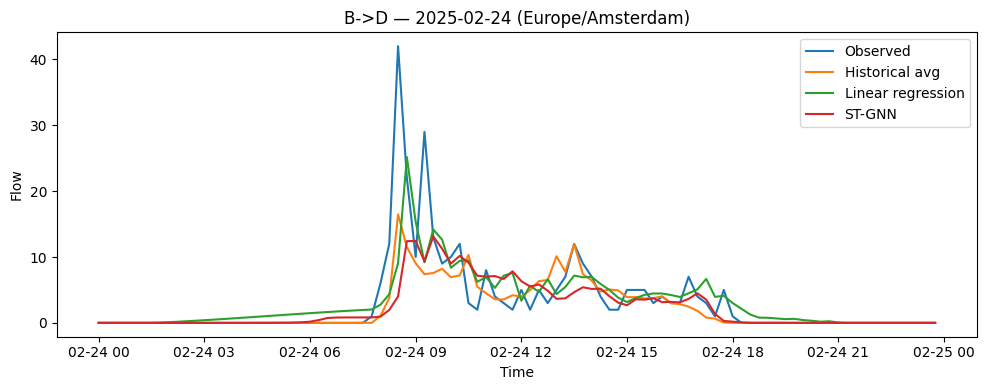

In [ ]:
from zoneinfo import ZoneInfo

# --- choose edge + day ---
edge_uv = ('B', 'D')        # change me
day_str = '2025-02-24'      # change me

u, v = edge_uv
edge_label = f'{u}->{v}'

# map (u,v) -> edge index
edge_map = getattr(net_cfg, 'edge_index', None) or getattr(net_cfg, 'index_edge', None)
if not edge_map:
    edge_map = {e: i for i, e in enumerate(net_cfg.directed_edges)}
edge_i = edge_map.get((u, v))
if edge_i is None:
    raise KeyError(f'Edge {edge_label} not found.')

# --- timezone: Europe/Amsterdam ---
AMS = ZoneInfo('Europe/Amsterdam')

# make a tz-aware "day start" in Amsterdam time
day0 = pd.Timestamp(day_str, tz=AMS).normalize()

# ensure `times` is also in Amsterdam time (localize if naive, else convert)
times_ams = (times.tz_localize('UTC').tz_convert(AMS)
             if getattr(times, 'tz', None) is None
             else times.tz_convert(AMS))

# build 1-day mask
mask = (times_ams >= day0) & (times_ams < day0 + pd.Timedelta('1D'))
if not mask.any():
    raise ValueError(f'No samples on {day0.date()} (range: {times_ams.min().date()} → {times_ams.max().date()}).')

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times_ams[mask], X[mask, edge_i],             label='Observed')
ax.plot(times_ams[mask], Xhat_baseline[mask, edge_i], label='Historical avg')
ax.plot(times_ams[mask], Xhat_reg[mask, edge_i],      label='Linear regression')
ax.plot(times_ams[mask], Xhat_gnn[mask, edge_i],      label='ST-GNN')
ax.set(title=f'{edge_label} — {day0.date()} (Europe/Amsterdam)', xlabel='Time', ylabel='Flow')
ax.legend(); fig.tight_layout(); plt.show()


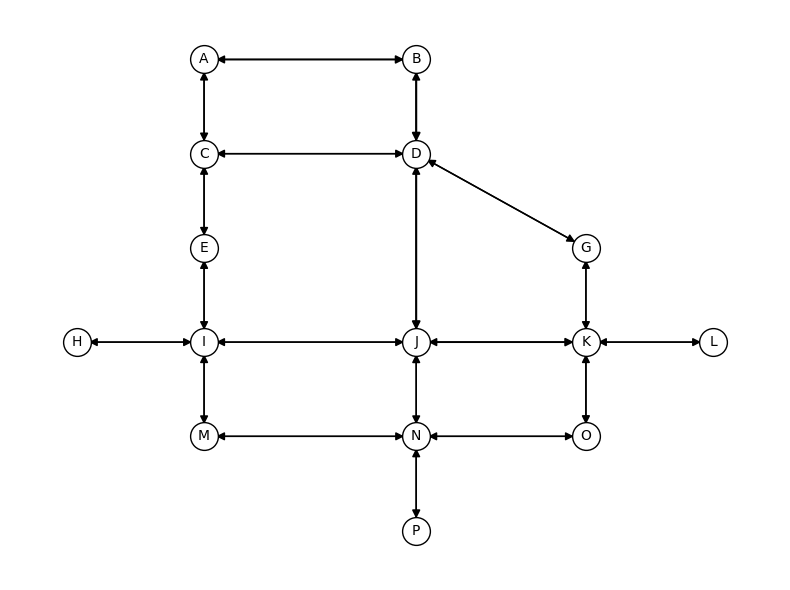

In [ ]:
# Build edge->value mapping for a chosen timestamp (e.g., mid-day in test)
t_idx = int(np.where(mask)[0].mean())
edge_values = { net_cfg.index_edge[i] if hasattr(net_cfg, "index_edge") and net_cfg.index_edge
                else net_cfg.directed_edges[i]: float(Xhat_gnn[t_idx, i]) for i in range(E) }
VIZ.draw_network_flows(edge_values, net_cfg)  # :contentReference[oaicite:27]{index=27}


Test MAE (masked):
  Historical average: 0.661
  Linear regression:  0.675
  ST-GNN:             0.711


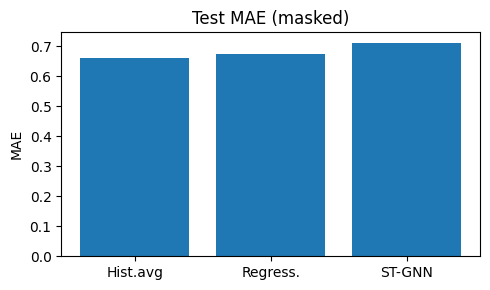

In [ ]:
# Compute MAE over the test slice for each model, masking like your training
sl = splits["test"]
def masked_mae_np(yhat, y, m):
    num = np.abs(yhat - y) * m
    return float(num.sum() / np.clip(m.sum(), 1.0, None))

mae_baseline = masked_mae_np(Xhat_baseline[sl], X[sl], M[sl])
mae_reg      = masked_mae_np(Xhat_reg[sl],      X[sl], M[sl])
# For the GNN, use timeline rollout for apples-to-apples aggregation
mae_gnn      = masked_mae_np(Xhat_gnn[sl],      X[sl], M[sl])

print(f'Test MAE (masked):')
print(f'  Historical average: {mae_baseline:.3f}')
print(f'  Linear regression:  {mae_reg:.3f}')
print(f'  ST-GNN:             {mae_gnn:.3f}')

plt.figure(figsize=(5,3))
plt.bar(['Hist.avg','Regress.','ST-GNN'], [mae_baseline, mae_reg, mae_gnn])
plt.ylabel('MAE')
plt.title('Test MAE (masked)')
plt.tight_layout(); plt.show()


In [ ]:
import networkx as nx
import matplotlib.colors as mcolors
import matplotlib.cm as cm

def _select_by_h(df_edge_time, use_closest=True):
    if use_closest:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='first'))
    else:
        return (df_edge_time.sort_values(['timestamp','h'])
                           .drop_duplicates(['timestamp','edge'], keep='last'))

def _mae_rmse_on_observed(df_edge_day):
    g = df_edge_day[df_edge_day['observed']]
    if g.empty:
        return np.nan, np.nan
    err = g['pred'] - g['true']
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    return mae, rmse

def _edge_peak_tables(df_day_sel: pd.DataFrame) -> pd.DataFrame:
    # 0) ensure 'edge' column exists (fallback from u/v)
    if 'edge' not in df_day_sel.columns:
        df_day_sel = df_day_sel.copy()
        df_day_sel['edge'] = df_day_sel['u'].astype(str) + '->' + df_day_sel['v'].astype(str)

    # 1) TRUE peaks (use observed bins only)
    obs = df_day_sel[df_day_sel.get('observed', True)].copy()

    if obs.empty:
        # build an empty but correctly-typed table
        cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak',
                'abs_err_at_true_peak','peak_pred','t_pred_peak','true_at_pred_peak',
                'abs_err_at_pred_peak','mae_day','rmse_day','observed_bins','total_bins','observed_frac']
        return pd.DataFrame(columns=cols)

    obs_sorted = obs.sort_values(['edge','true'], ascending=[True, False])
    true_peaks = (obs_sorted.groupby('edge', as_index=False)
                           .first()[['edge','u','v','timestamp','true']]
                           .rename(columns={'timestamp':'t_true_peak','true':'peak_true'}))

    # predicted value at the time of the TRUE peak
    pred_at_true_peak = (df_day_sel[['edge','timestamp','pred']]
                         .merge(true_peaks[['edge','t_true_peak']],
                                left_on=['edge','timestamp'],
                                right_on=['edge','t_true_peak'],
                                how='right')
                         .rename(columns={'pred':'pred_at_true_peak'})
                         [['edge','pred_at_true_peak']])

    # 2) PRED peaks (on selected horizon rows)
    sel_sorted = df_day_sel.sort_values(['edge','pred'], ascending=[True, False])
    pred_peaks = (sel_sorted.groupby('edge', as_index=False)
                           .first()[['edge','timestamp','pred','true','observed']]
                           .rename(columns={'timestamp':'t_pred_peak','pred':'peak_pred',
                                            'true':'true_at_pred_peak','observed':'obs_at_pred_peak'}))

    # 3) Per-edge day stats (MAE/RMSE on observed bins only)
    stats_rows = []
    for e, g in df_day_sel.groupby('edge'):
        g_obs = g[g.get('observed', True)]
        if g_obs.empty:
            mae = rmse = np.nan
            obs_cnt = 0
        else:
            err = (g_obs['pred'] - g_obs['true']).to_numpy()
            mae = np.abs(err).mean()
            rmse = np.sqrt((err**2).mean())
            obs_cnt = int(g_obs.shape[0])
        tot_cnt = int(g.shape[0])
        stats_rows.append({
            'edge': e, 'mae_day': mae, 'rmse_day': rmse,
            'observed_bins': obs_cnt, 'total_bins': tot_cnt,
            'observed_frac': (obs_cnt / max(1, tot_cnt))
        })
    day_stats = pd.DataFrame(stats_rows)

    # 4) Join everything on a *column* 'edge'
    tbl = (true_peaks
           .merge(pred_at_true_peak, on='edge', how='left')
           .merge(pred_peaks,       on='edge', how='left')
           .merge(day_stats,        on='edge', how='left'))

    # 5) Absolute errors at peak times
    tbl['abs_err_at_true_peak'] = (tbl['pred_at_true_peak'] - tbl['peak_true']).abs()
    tbl['abs_err_at_pred_peak'] = (tbl['peak_pred'] - tbl['true_at_pred_peak']).abs()

    # nice ordering
    cols = ['edge','u','v','peak_true','t_true_peak','pred_at_true_peak','abs_err_at_true_peak',
            'peak_pred','t_pred_peak','true_at_pred_peak','abs_err_at_pred_peak',
            'mae_day','rmse_day','observed_bins','total_bins','observed_frac']
    return tbl[cols].sort_values('peak_true', ascending=False).reset_index(drop=True)



def _plot_network_values(POS, edges, values, title, vmin=None, vmax=None, cmapname='viridis', show_arrows=True, ax=None):
    if ax is None: ax = plt.gca()
    G = nx.DiGraph(); G.add_nodes_from(POS.keys()); G.add_edges_from(edges)
    edgelist = list(edges)

    vals = np.array([values.get((u,v), np.nan) for (u,v) in edgelist], float)
    # choose scale
    if vmin is None: vmin = float(np.nanmin(vals)) if np.isfinite(vals).any() else 0.0
    if vmax is None: vmax = float(np.nanmax(vals)) if np.isfinite(vals).any() else 1.0
    if not np.isfinite(vmin): vmin = 0.0
    if (not np.isfinite(vmax)) or vmax <= vmin: vmax = vmin + 1.0

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmapname)
    # colors: NaNs -> light gray
    colors = [cmap(norm(v)) if np.isfinite(v) else (0.85,0.85,0.85,1.0) for v in vals]
    # # widths: based on |value| so negatives still visible (error panel)
    # scale = vmax - vmin if vmax > vmin else 1.0
    # widths = 1.0 + 4.0 * (np.abs(vals - (vmin + scale/2.0)) / (scale/2.0))
    # widths = np.clip(widths, 0.5, 5.0)
    widths = np.full_like(vals, 2.0, dtype=float)


    ax.set_title(title)
    nx.draw_networkx_nodes(G, POS, node_size=300, node_color='lightgray', edgecolors='k', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(G, POS, edgelist=edgelist, width=widths,
                           edge_color=colors, arrows=show_arrows,
                           arrowstyle='-|>', arrowsize=10, ax=ax)
    nx.draw_networkx_labels(G, POS, font_size=9, ax=ax)

    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    ax.figure.colorbar(sm, ax=ax, shrink=0.75).set_label('value')
    ax.set_axis_off()
    return sm

In [ ]:
# === Moment snapshot per directed edge (TRUE / PRED / ERROR) ===
# Requirements in scope: df_pred with columns ['timestamp','u','v','true','pred','observed', 'h' (optional)],
#                        POS, DIRECTED_EDGES, and the helpers: _select_by_h, _plot_network_values

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

# ------- choose the moment -------
# Option A: set local Amsterdam day+time directly
day_str  = '2025-04-24'    # change me
time_str = '14:00'         # change me

# Option B (alternative): if the old notebook stored UTC clock time, set it here and we'll convert
prev_notebook_time_utc = None   # e.g. '2025-04-24 10:00'  (leave as None if using A)

use_closest = True  # if the exact bin isn't present, pick nearest within the day

AMS = ZoneInfo('Europe/Amsterdam')

# --- normalize timestamps to Amsterdam time for selection/labels ---
ts = df_pred['timestamp']
ts_ams = (ts.dt.tz_localize('UTC').dt.tz_convert(AMS)) if ts.dt.tz is None else ts.dt.tz_convert(AMS)

if prev_notebook_time_utc:
    # old notebook moment (UTC) -> Amsterdam moment
    t_req_ams = pd.Timestamp(prev_notebook_time_utc, tz='UTC').tz_convert(AMS)
else:
    t_req_ams = pd.Timestamp(f"{day_str} {time_str}", tz=AMS)

# filter to the same local day
df_day = df_pred[ts_ams.dt.date == t_req_ams.date()].copy()
if df_day.empty:
    raise ValueError(f"No predictions for local day {t_req_ams.date()} in df_pred.")

# resolve horizon duplicates first
df_day = _select_by_h(df_day, use_closest=use_closest)

# choose the bin at/nearest to the requested time (within that day)
ts_ams_day = ts_ams.loc[df_day.index]
if (ts_ams_day == t_req_ams).any():
    t_sel_ams = t_req_ams
else:
    # nearest within the day
    diffs = np.abs(ts_ams_day.values.astype('datetime64[ns]') - t_req_ams.to_datetime64())
    t_sel_ams = pd.Timestamp(ts_ams_day.values[int(np.argmin(diffs))]).tz_convert(AMS)
    if use_closest:
        print(f"Using closest timestamp on {t_req_ams.date()}: requested {t_req_ams.time()},"
              f" selected {t_sel_ams.time()}")

# rows at the selected moment (in original df timezone)
df_t = df_day.loc[ts_ams_day == t_sel_ams].copy()
if 'edge' not in df_t.columns:
    df_t['edge'] = df_t['u'].astype(str) + '->' + df_t['v'].astype(str)

# --- build per-edge dicts for plotting at that moment ---
edge_true, edge_pred, edge_err = {}, {}, {}
for (u, v), g in df_t.groupby(['u', 'v']):
    pred = float(g['pred'].iloc[0]); edge_pred[(u, v)] = pred
    if bool(g['observed'].iloc[0]):
        tru = float(g['true'].iloc[0])
    else:
        tru = np.nan
    edge_true[(u, v)] = tru
    edge_err[(u, v)]  = (pred - tru) if np.isfinite(tru) else np.nan

# common scales
vmax_tp = max(1.0, np.nanmax([*edge_true.values(), *edge_pred.values(), 1.0]))
err_vals = np.array([v for v in edge_err.values() if np.isfinite(v)])
err_max  = float(np.nanmax(np.abs(err_vals))) if err_vals.size else 1.0

# --- plot three panels (vertical like your previous notebook) ---
fig, axs = plt.subplots(3, 1, figsize=(5, 16), constrained_layout=True)
_plot_network_values(POS, DIRECTED_EDGES, edge_true,
                     f"TRUE @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')}",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[0])
_plot_network_values(POS, DIRECTED_EDGES, edge_pred,
                     f"PRED @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')} (h={'min' if use_closest else 'max'})",
                     vmin=0, vmax=vmax_tp, cmapname='viridis', ax=axs[1])
_plot_network_values(POS, DIRECTED_EDGES, edge_err,
                     f"ERROR (pred−true, observed only) @ {t_sel_ams.strftime('%Y-%m-%d %H:%M')}",
                     vmin=-err_max, vmax=err_max, cmapname='coolwarm', ax=axs[2])
plt.show()


ValueError: No predictions for local day 2025-04-24 in df_pred.